# Bài tập lý thuyết tuần 5
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH (Sáng thứ 6)

### Bài tập: 

Phân tích ra thừa số nguyên tố (đệ quy)

<center>
Bài làm
</center>

Mã giả như sau:

```python
List primeFactorsTail(int n, int d, List acc) {
    if (n > 1) {
        if (d * d > n) {
            acc.add(n);
            return acc;
        }
        if (n % d == 0) {
            acc.add(d);
            return primeFactorsTail(n / d, d, acc);
        }
        return primeFactorsTail(n, d + 1, acc);
    }
    return acc;
}
```

ghi lại dưới dạng toán

$$T(n, d) = \begin{cases} 
c_0 & \text{nếu } n \le 1 \text{ hoặc } d^2 > n \\ 
T(n/d, d) + c_1 & \text{nếu } n \pmod d = 0 \\ 
T(n, d+1) + c_2 & \text{nếu } n \pmod d \neq 0 
\end{cases}$$
- Xét bài toán theo các trường hợp
    - Worst case: 
    $$T(n, 2) = T(n, 3) + c_2$$
    $$T(n, 2) = [T(n, 4) + c_2] + c_2 = T(n, 4) + 2c_2$$
    $$T(n, 2) = [T(n, 5) + c_2] + 2c_2 = T(n, 5) + 3c_2$$
    Khai triển tổng quát sau $k$ bước lặp (với biến chia tiến tới giá trị $2 + k$):
    $$T(n, 2) = T(n, 2+k) + k c_2$$
    Dừng lai khi $2 + k > \sqrt{n} \Rightarrow k > \sqrt{n} - 2$. Do đó, ta có:
    $$T(n, 2) = T(n, 2 + \lceil \sqrt{n} \rceil) + \lceil \sqrt{n} \rceil c_2 = T(n, \lceil \sqrt{n} \rceil) + \lceil \sqrt{n} \rceil c_2$$
    Nên độ phức tạp của trường hợp này là $O(\sqrt{n})$.
    - Best case (Trường hợp tốt nhất):
    $$T(2^m, 2) = T(2^{m-1}, 2) + c_1$$
    $$T(2^m, 2) = [T(2^{m-2}, 2) + c_1] + c_1 = T(2^{m-2}, 2) + 2c_1$$
    $$T(2^m, 2) = [T(2^{m-3}, 2) + c_1] + 2c_1 = T(2^{m-3}, 2) + 3c_1$$
    Khai triển tổng quát sau $k$ bước lặp:
    $$T(2^m, 2) = T(2^{m-k}, 2) + k c_1$$
    Quá trình dừng lại khi $m - k \le 0 \implies k \ge m$. Do đó, ta có:$$T(2^m, 2) = T(1, 2) + m c_1 = O(m)$$Với $m = \log_2 n$, nên độ phức tạp của trường hợp này là $O(\log n)$.

### Bài tập: 


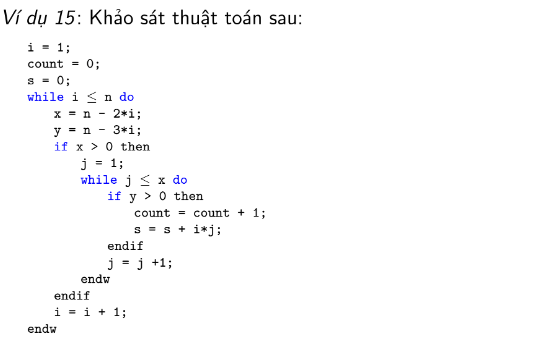

```
i = 1;
count = 0;
s = 0;
while i <= n do
    x = n - 2*i;
    y = n - 3*i;
    if x > 0 then
        j = 1;
        while j <= x do
            if y > 0 then
                count = count + 1;
                s = s + i*j;
            endif
            j = j + 1;
        endw
    endif
    i = i + 1;
endw
```

> Số phép gán:

Trước hết ta có 3 phép gán:
```
i = 1;
count = 0;
s = 0;
```

Trong vòng lặp while i <= n thì mỗi vòng lặp ta luôn luôn có 3 phép gán sau:
```
x = n - 2*i;
y = n - 3*i;
i = i + 1;
```
Do đó, số phép gán trong vòng lặp while i <= n sẽ là 3n.

Ở trong vòng lặp while i <= n thì có điều kiện if x > 0 thì ta có phép gán `j = 1` sẽ xảy ra khi n - 2*i > 0, tức là khi i < n/2. Mà i <= n nên ta có số lần gán `j = 1` sẽ là:
- Gọi $e_i \in \{0, 1\}$ là số lần gán `j = 1` ở vòng lặp thứ i thì ta có tổng phép gán `j = 1` trong vòng lặp while i <= n sẽ là: $\sum_{i=1}^{n/2} e_i \leq n/2$ (vì mỗi vòng lặp i thì $e_i$ chỉ có thể là 0 hoặc 1 nên tổng $\sum_{i=1}^{n/2} e_i$ sẽ nhỏ hơn hoặc bằng n/2) 

Trong vòng lặp while j <= x của while i <= n thì có phép gán `count = count + 1` sẽ xảy ra khi y > 0, tức là khi n - 3*i > 0, tức là khi i < n/3. Mà i <= n nên ta có số lần gán `count = count + 1` sẽ là:
- Gọi $f_i \in \{0, 1\}$ là số lần gán `count = count + 1` ở vòng lặp thứ i thì ta có tổng phép gán `count = count + 1` trong vòng lặp while i <= n sẽ là: $\sum_{i=1}^{n/2} \sum_{i=1}^{n/3} f_i \leq (n/2) * (n/3) = n^2/6$ (vì mỗi vòng lặp i thì $f_i$ chỉ có thể là 0 hoặc 1 nên tổng $\sum_{i=1}^{n/2} \sum_{i=1}^{n/3} f_i$ sẽ nhỏ hơn hoặc bằng (n/2) * (n/3)) 

Trong vòng lặp while j <= x của while i <= n có điều kiện if y > 0 thì ta có phép gán `s = s + i*j` sẽ xảy ra khi y > 0, tức là khi n - 3*i > 0, tức là khi i < n/3. Mà i <= n nên ta có số lần gán `s = s + i*j` sẽ là:
- Gọi $g_i \in \{0, 1\}$ là số lần gán `s = s + i*j` ở vòng lặp thứ i thì ta có tổng phép gán `s = s + i*j` trong vòng lặp while i <= n sẽ là: $\sum_{i=1}^{n/2} \sum_{i=1}^{n/3} 2g_i \leq 2 * (n/2) * (n/3) = n^2/3$ (vì mỗi vòng lặp i thì $g_i$ chỉ có thể là 0 hoặc 1 nên tổng $\sum_{i=1}^{n/2} \sum_{i=1}^{n/3} 2g_i$ sẽ nhỏ hơn hoặc bằng 2 * (n/2) * (n/3))


Như vậy tổng số phép gán trong thuật toán sẽ là:  $$3 + 3n + n/2 + n^2/6 + n^2/3 = 3 + 3n + n/2 + n^2/2 = 3 + (3n + n/2) + n^2/2 = 3 + 7n/2 + n^2/2$$


> Số phép so sánh:

trong thuật toán trên, ta có những phép so sánh là:
```
while i <= n 
    ...
    if x > 0 then
        ...
        while j <= x do
            if y > 0 then
                ...
            endif
            ...
        endw
    endif
    ...
endw
```

Trong vòng lặp while i <= n thì sẽ có n + 1 phép so sánh (vì khi i = n + 1 thì điều kiện i <= n sẽ sai nên ta có n + 1 phép so sánh)

Ở trong điều kiện if x > 0 trong vòng lặp while i <= n thì ta có n phép so sánh (vì mỗi vòng lặp i thì sẽ có 1 phép so sánh x > 0)

Ở trong vòng lặp while j <= x của while i <= n thì ta có $\sum_{i=1}^{n/2} (\sum_{i=1}^{n/3} h_i + 1)$ phép so sánh với $h_i \in \{0, 1\}$ là số lần so sánh y > 0 ở vòng lặp thứ i. Mà y = n - 3*i nên ta có $h_i$ sẽ bằng 1 khi i < n/3 và bằng 0 khi i >= n/3. Do đó, ta có $\sum_{i=1}^{n/2} (\sum_{i=1}^{n/3} h_i + 1) \leq (n/2) * (n/3 + 1) = n^2/6 + n/2$ (vì mỗi vòng lặp i thì $h_i$ chỉ có thể là 0 hoặc 1 nên tổng $\sum_{i=1}^{n/2} (\sum_{i=1}^{n/3} h_i + 1)$ sẽ nhỏ hơn hoặc bằng (n/2) * (n/3 + 1))

Như vậy tổng số phép so sánh trong thuật toán sẽ là: $$n + 1 + n + n^2/6 + n/2 = 1 + 2n + n/2 + n^2/6 = 1 + (2n + n/2) + n^2/6 = 1 + 5n/2 + n^2/6$$

Tổng số phép gán + Tổng số phép so sánh = $T(n) = (3 + 7n/2 + n^2/2) + (1 + 5n/2 + n^2/6) = 4 + 6n + 2n^2/3$

Vậy thuật toán có độ phức tạp là $O(n^2)$.
